# Regression Validation Demo

This notebook creates synthetic continuous-outcome datasets and validates the new regression mode for:

- `MESA_modality(task="regression")`
- `MESA(task="regression")`
- `MESA_CV(task="regression")`

It is designed as a focused regression test case rather than a biological analysis notebook.


In [22]:
from mesa import MESA_modality, MESA, MESA_CV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error

plt.rcParams['figure.figsize'] = (7, 5)
RNG = np.random.RandomState(42)


## Build synthetic multimodal regression data

We generate two modalities driven by partly shared latent signals and a continuous target.
This gives the stacked regression model a reason to combine modalities.


In [23]:
n_samples = 180

signal_a = RNG.normal(size=n_samples)
signal_b = RNG.normal(size=n_samples)
signal_c = RNG.normal(size=n_samples)
noise = RNG.normal(scale=0.6, size=n_samples)

y = 2.5 * signal_a - 1.7 * signal_b + 0.9 * signal_c + noise

X1_core = np.column_stack([
    signal_a + RNG.normal(scale=0.10, size=n_samples),
    0.8 * signal_a + RNG.normal(scale=0.15, size=n_samples),
    signal_b + RNG.normal(scale=0.20, size=n_samples),
    signal_c + RNG.normal(scale=0.25, size=n_samples),
])
X1_noise, _ = make_regression(
    n_samples=n_samples,
    n_features=16,
    n_informative=3,
    noise=8.0,
    random_state=1,
)
X1 = pd.DataFrame(
    np.column_stack([X1_core, X1_noise]),
    columns=[f'mod1_feature_{i}' for i in range(20)],
)

X2_core = np.column_stack([
    signal_b + RNG.normal(scale=0.10, size=n_samples),
    0.7 * signal_b + RNG.normal(scale=0.15, size=n_samples),
    signal_c + RNG.normal(scale=0.12, size=n_samples),
    0.5 * signal_a + RNG.normal(scale=0.20, size=n_samples),
])
X2_noise, _ = make_regression(
    n_samples=n_samples,
    n_features=12,
    n_informative=2,
    noise=10.0,
    random_state=2,
)
X2 = pd.DataFrame(
    np.column_stack([X2_core, X2_noise]),
    columns=[f'mod2_feature_{i}' for i in range(16)],
)

X1.shape, X2.shape, y.shape


((180, 20), (180, 16), (180,))

## Train/test split

In [24]:
train_index = np.arange(0, 130)
test_index = np.arange(130, n_samples)

X1_train, X1_test = X1.iloc[train_index], X1.iloc[test_index]
X2_train, X2_test = X2.iloc[train_index], X2.iloc[test_index]
y_train, y_test = y[train_index], y[test_index]

X1_train.shape, X1_test.shape, X2_train.shape, X2_test.shape


((130, 20), (50, 20), (130, 16), (50, 16))

## Single-modality regression

This validates that `MESA_modality(task="regression")` fits, predicts, and returns selected features.


In [25]:
single_modality = MESA_modality(
    task='regression',
    top_n=8,
    selector=14,
    predictor=RandomForestRegressor(n_estimators=100, random_state=0),
    boruta_estimator=RandomForestRegressor(n_estimators=100, random_state=0),
    redundancy_pruning='score',
    redundancy_threshold=0.95,
    random_state=0,
)

single_modality.fit(X1_train, y_train)
pred_1 = single_modality.transform_predict(X1_test)
r2_1 = r2_score(y_test, pred_1)
rmse_1 = mean_squared_error(y_test, pred_1) ** 0.5

print('Single-modality R2:', round(r2_1, 4))
print('Single-modality RMSE:', round(rmse_1, 4))
print('Selected feature count:', len(single_modality.get_support()))
print('Selected features:', X1.columns[single_modality.get_support()].tolist())


Single-modality R2: 0.8171
Single-modality RMSE: 1.4024
Selected feature count: 8
Selected features: ['mod1_feature_0', 'mod1_feature_2', 'mod1_feature_3', 'mod1_feature_12', 'mod1_feature_7', 'mod1_feature_10', 'mod1_feature_13', 'mod1_feature_5']


In [26]:
try:
    modality_1.transform_predict_proba(X1_test)
except ValueError as exc:
    print('Expected regression-mode error:', exc)


Expected regression-mode error: transform_predict_proba is only available when task='classification'.


## Multi-modality regression ensemble

This validates that `MESA(task="regression")` stacks scalar predictions instead of class probabilities.


In [27]:
modality_1 = MESA_modality(
    task='regression',
    top_n=8,
    selector=14,
    predictor=RandomForestRegressor(n_estimators=100, random_state=0),
    boruta_estimator=RandomForestRegressor(n_estimators=100, random_state=0),
    random_state=0,
)

modality_2 = MESA_modality(
    task='regression',
    top_n=6,
    selector=12,
    predictor=Ridge(alpha=1.0),
    boruta_estimator=RandomForestRegressor(n_estimators=100, random_state=0),
    random_state=0,
)

mesa_reg = MESA(
    task='regression',
    modalities=[modality_1, modality_2],
    meta_estimator=LinearRegression(),
    random_state=0,
)

mesa_reg.fit([X1_train, X2_train], y_train)
mesa_pred = mesa_reg.predict([X1_test, X2_test])
mesa_r2 = r2_score(y_test, mesa_pred)
mesa_rmse = mean_squared_error(y_test, mesa_pred) ** 0.5

print('MESA regression R2:', round(mesa_r2, 4))
print('MESA regression RMSE:', round(mesa_rmse, 4))
print('Per-modality selected feature counts:', [len(x) for x in mesa_reg.get_support()])


MESA regression R2: 0.9118
MESA regression RMSE: 0.9738
Per-modality selected feature counts: [8, 6]


In [28]:
try:
    mesa_reg.predict_proba([X1_test, X2_test])
except ValueError as exc:
    print('Expected regression-mode error:', exc)


Expected regression-mode error: predict_proba is only available when task='classification'.


## Cross-validation regression metrics

This validates default R² scoring plus alternative regression metrics in `MESA_CV`.


In [29]:
cv_modality = MESA_modality(
    task='regression',
    top_n=8,
    selector=14,
    predictor=LinearRegression(),
    boruta_estimator=RandomForestRegressor(n_estimators=100, random_state=0),
    random_state=0,
)

cv_eval = MESA_CV(
    modality=cv_modality,
    task='regression',
    random_state=0,
)
cv_eval.fit(X1, y)

metrics = {
    'r2': cv_eval.get_performance(),
    'neg_root_mean_squared_error': cv_eval.get_performance(metric='neg_root_mean_squared_error'),
    'pearson': cv_eval.get_performance(metric='pearson'),
    'spearman': cv_eval.get_performance(metric='spearman'),
}

pd.Series(metrics, name='cv_score')


@Tue Mar 10 18:55:54 2026 	Single modality input


r2                             0.909327
neg_root_mean_squared_error   -0.829341
pearson                        0.962637
spearman                       0.954749
Name: cv_score, dtype: float64

## Diagnostic plots

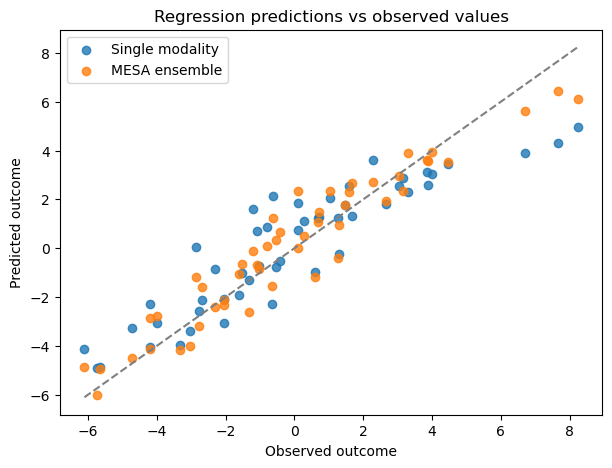

In [30]:
plt.scatter(y_test, pred_1, alpha=0.8, label='Single modality')
plt.scatter(y_test, mesa_pred, alpha=0.8, label='MESA ensemble')
min_val = min(y_test.min(), pred_1.min(), mesa_pred.min())
max_val = max(y_test.max(), pred_1.max(), mesa_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='grey')
plt.xlabel('Observed outcome')
plt.ylabel('Predicted outcome')
plt.title('Regression predictions vs observed values')
plt.legend()
plt.show()


In [31]:
summary = pd.DataFrame(
    {
        'single_modality': {
            'r2': r2_1,
            'rmse': rmse_1,
            'n_features': len(single_modality.get_support()),
        },
        'mesa_regression': {
            'r2': mesa_r2,
            'rmse': mesa_rmse,
            'n_features': sum(len(x) for x in mesa_reg.get_support()),
        },
    }
).T
summary


,r2,rmse,n_features
single_modality,0.817108,1.402424,8.0
mesa_regression,0.911816,0.973816,14.0


## Expected checks

When this notebook runs successfully, it should demonstrate:

- regression `fit()` and `predict()` paths work for `MESA_modality`
- `transform_predict_proba()` raises a clear error in regression mode
- multimodal regression stacking works in `MESA`
- `predict_proba()` raises a clear error for regression `MESA`
- `MESA_CV` returns finite regression metrics
- selected feature indices are available through `get_support()`
